# 지경학적 분절화는 서비스 교역에서도 일어나는가 — 재현 노트북

`지경학적_분절화와_서비스교역.md`의 수치와 그림을 다시 만든다.

1. `blocs.py`로 네 가지 블록 정의를 만들고
2. `analysis.py`로 모든 수치(`out/stats.json`)와 그림(`img/`)을 만든 뒤
3. 핵심 지표를 분석 스크립트와 무관한 SQL로 한 번 더 계산해 맞춰 보고
4. 마지막 절(§9)에서 본문이 인용한 수치를 대조한다.

필요한 것: 이 저장소의 `svcdb.duckdb`, TradeNetworkAtlas 프로젝트의 `baci_net.duckdb`,
`data/external/unga/`의 이념점수(`fetch_unga.py`), 패키지 `duckdb pandas numpy matplotlib igraph leidenalg`.

## §0. 경로

In [1]:
import os, json, subprocess, sys
import duckdb
import numpy as np
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 160)

HERE = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(HERE, "analysis.py")) or "2.지경학적" not in HERE:
    cand = os.path.join(HERE, "research", "2.지경학적_분절화와_서비스교역")
    if os.path.exists(cand):
        HERE = cand
        break
    up = os.path.dirname(HERE)
    if up == HERE:
        raise FileNotFoundError("연구 폴더를 찾지 못했다")
    HERE = up
ROOT = os.path.dirname(os.path.dirname(HERE))
DB = os.path.join(ROOT, "data", "processed", "svcdb.duckdb")
print(HERE)

C:\Work\Projects\Services\research\2.지경학적_분절화와_서비스교역


## §1. 블록 정의

In [2]:
r = subprocess.run([sys.executable, os.path.join(HERE, "blocs.py")], capture_output=True, text=True, encoding="utf-8")
print(r.stdout[-2500:]); assert r.returncode == 0, r.stderr
blocs = pd.read_csv(os.path.join(HERE, "out", "blocs.csv"))
blocs[["D1", "D2", "D3", "D4"]].apply(lambda s: s.value_counts()).fillna(0).astype(int)

경제 수 211
D1 {'NON': 95, 'US': 58, 'CN': 51, nan: 7}
D2 {'NON': 96, 'US': 57, 'CN': 50, nan: 8}
D3 {'NON': 147, 'US': 56, 'CN': 8}
D4 {'CN': 148, 'US': 56, nan: 7}

D1과 D2가 다른 경제: 96 | 예: [['AGO', 'NON', 'CN'], ['ARE', 'NON', 'CN'], ['ATG', 'CN', 'NON'], ['AZE', 'NON', 'CN'], ['BDI', 'NON', 'CN'], ['BFA', 'NON', 'CN'], ['BGD', 'NON', 'CN'], ['BHR', 'NON', 'CN'], ['BHS', 'CN', 'NON'], ['BLZ', 'CN', 'NON'], ['BOL', 'NON', 'CN'], ['BRA', 'CN', 'NON']]

주요국:
code  ip_2015_17  ip_2022_24  D1  D2  D3 D4
 ARE       -0.70       -0.59 NON  CN NON CN
 BRA       -0.45       -0.16  CN NON NON CN
 CHN       -0.35       -0.92  CN  CN  CN CN
 DEU        1.15        1.17  US  US  US US
 GBR        1.58        1.68  US  US  US US
 HKG       -0.35       -0.92  CN  CN  CN CN
 IDN       -0.96       -0.70 NON  CN NON CN
 IND       -0.26       -0.24  CN NON NON CN
 IRN       -1.53       -1.51 NON NON NON CN
 JPN        0.64        0.75  US  US  US US
 KOR        0.86        0.89  US  US  US US
 MEX       -0.

,D1,D2,D3,D4
CN,51,50,8,148
NON,95,96,147,0
US,58,57,56,56


## §2. 분석 실행 (몇 분 걸린다)

In [3]:
r = subprocess.run([sys.executable, os.path.join(HERE, "analysis.py")], capture_output=True, text=True, encoding="utf-8")
assert r.returncode == 0, r.stderr[-3000:]
S = json.load(open(os.path.join(HERE, "out", "stats.json"), encoding="utf-8"))
S["panel"]

{'n_pairs': 9196,
 'src_x': 5297,
 'src_m': 3862,
 'src_mixed': 37,
 'n_economies': 201,
 'usa_chn_in': True,
 'svc_cover_2019': 82.3,
 'svc_cover_2023': 83.8,
 'goods_cover_2019': 75.8,
 'goods_cover_2023': 74.1}

## §3. 표 2 — 사전 대비 사후 변화

In [4]:
main = pd.read_csv(os.path.join(HERE, "out", "main_changes.csv"))
main[["defn", "series", "S_pre", "d_pretrend", "d_war", "d_post", "dlogodds_post"]].round(3)

,defn,series,S_pre,d_pretrend,d_war,d_post,dlogodds_post
0,D1,svc_bal,20.704,0.864,0.140,-0.836,-0.052
1,D1,svc_rep,18.836,NaN,0.022,-1.546,-0.104
2,D1,goods_rx,31.393,0.251,-0.367,-1.019,-0.048
3,D1,goods_b,31.642,0.450,-0.327,-0.806,-0.038
4,D1,goods_baci,32.861,0.435,-0.144,-0.427,-0.019
5,D2,svc_bal,19.939,0.458,-0.543,-2.736,-0.181
6,D2,svc_rep,18.012,NaN,-0.666,-3.500,-0.258
7,D2,goods_rx,34.001,-1.208,-0.170,-2.076,-0.094
8,D2,goods_b,34.118,-1.031,-0.096,-1.762,-0.079
9,D2,goods_baci,35.328,-1.049,0.101,-1.566,-0.069


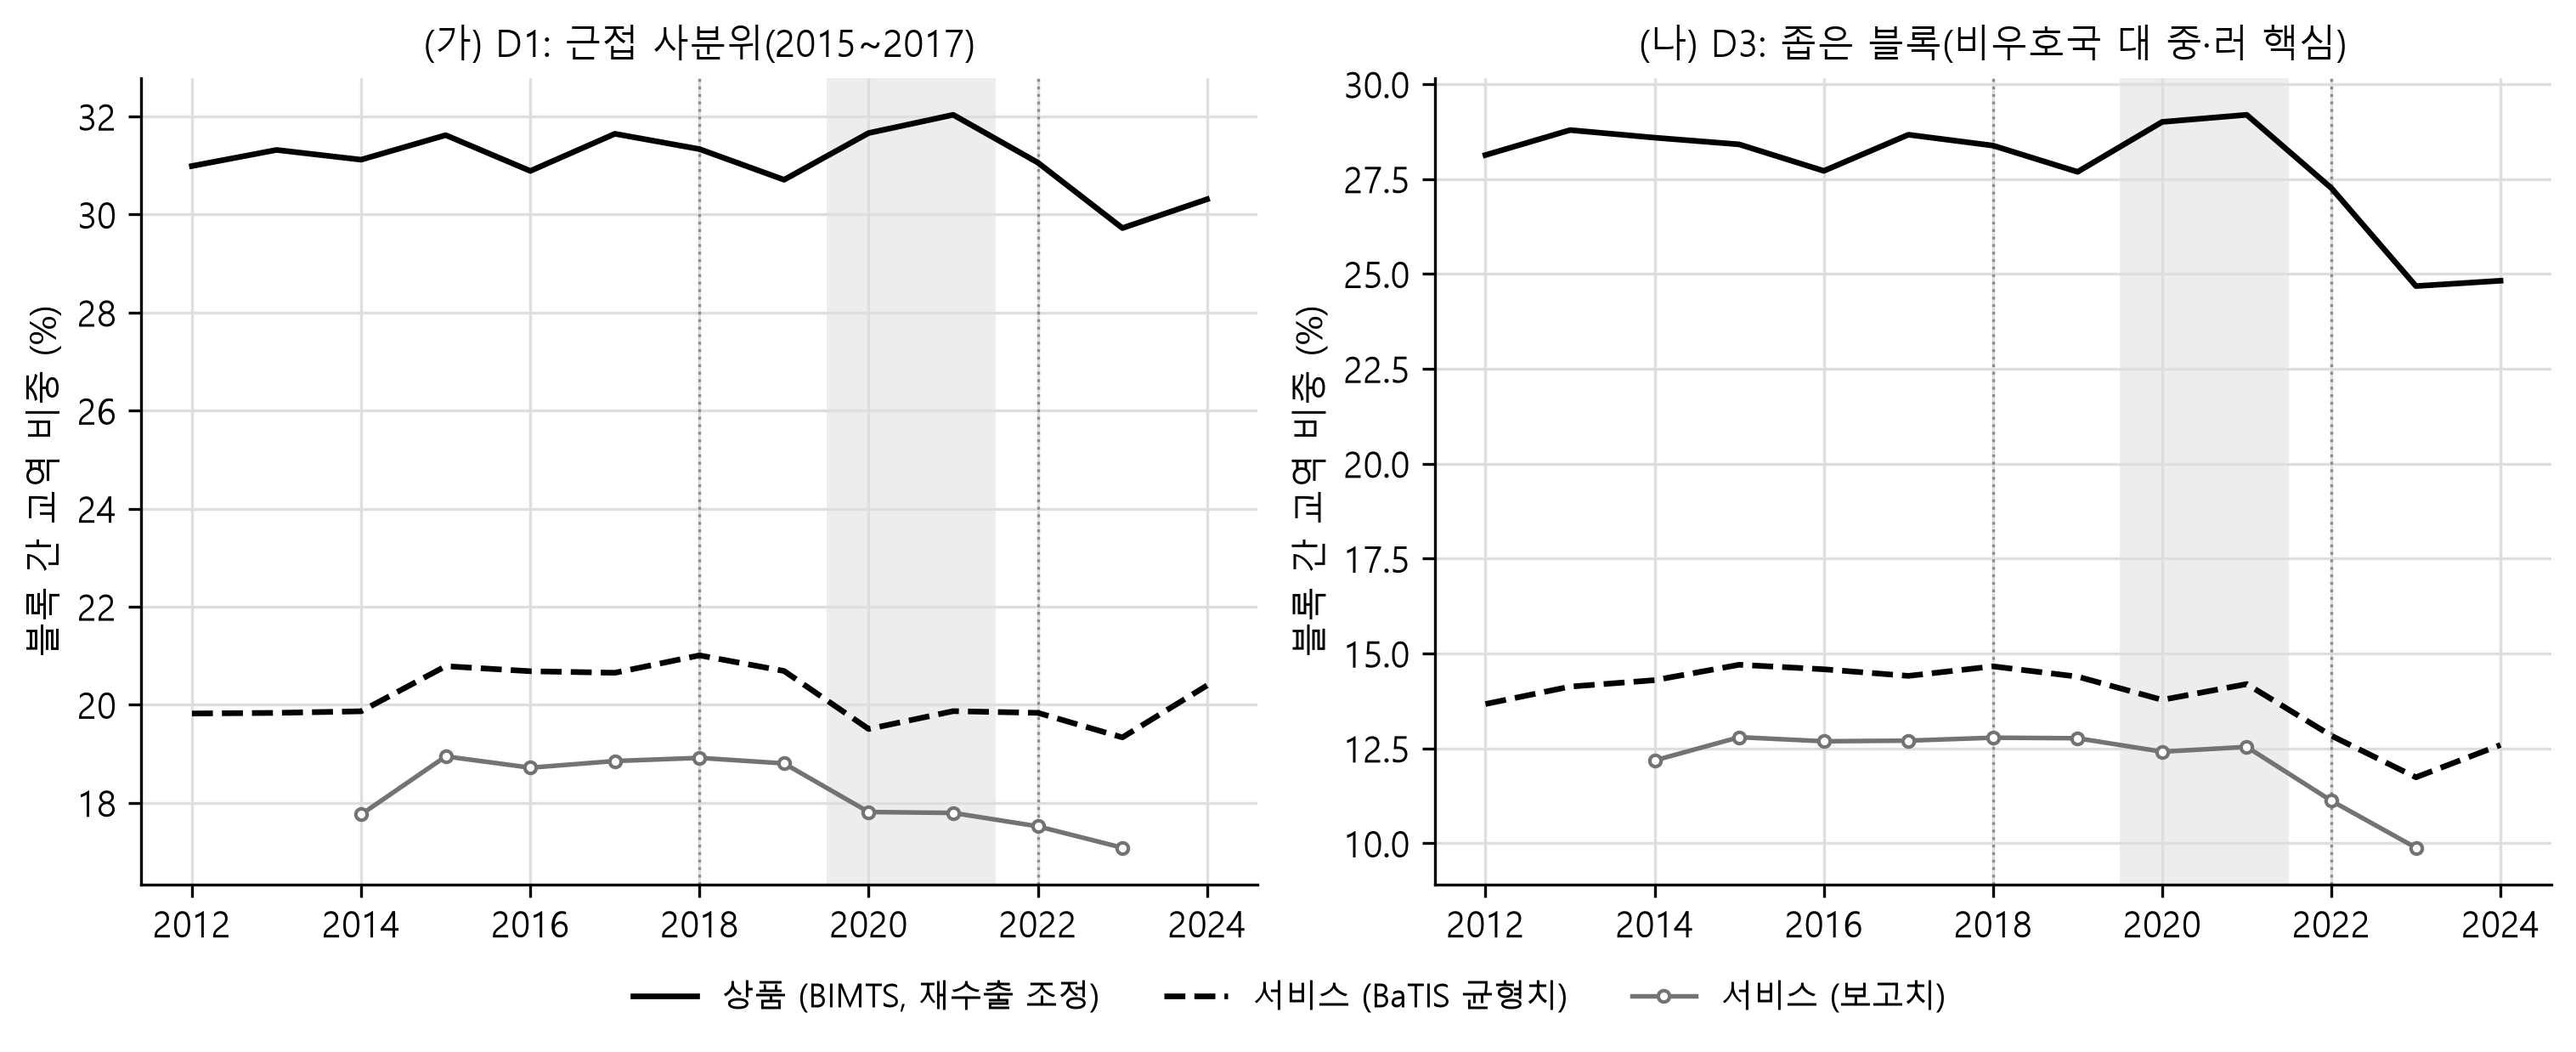

,lo,hi,n
svc_bal,-2.11,0.81,1000.0
svc_rep,-2.79,0.11,1000.0
goods_rx,-2.44,0.47,1000.0
diff_bal,-1.09,1.77,1000.0
diff_rep,-1.60,0.88,1000.0
n_exporters,105.00,105.00,105.0


In [5]:
display(Image(os.path.join(HERE, "img", "fig1_cross_share.png"), width=900))
pd.DataFrame(S["bootstrap_D1"]).T

## §4. 러시아와 대만·홍콩

In [6]:
print(pd.DataFrame(S["russia_exclusion"]).T)
print(S["russia_quality"])
print(pd.DataFrame(S["russia_mirror"]).T)
S["taiwan_hk_D1"]

             d_all  d_exrus
D1|svc_bal   -0.84    -0.82
D1|svc_rep   -1.55    -1.53
D1|goods_rx  -1.02    -1.00
D2|svc_bal   -2.74    -1.82
D2|svc_rep   -3.50    -2.78
D2|goods_rx  -2.08    -0.99
D3|svc_bal   -2.18    -1.11
D3|svc_rep   -2.25    -1.42
D3|goods_rx  -2.66    -1.44
D4|svc_bal   -1.06    -0.38
D4|svc_rep   -1.97    -1.44
D4|goods_rx  -1.43    -0.67
{'pre': {'x_pct': 78.1, 'mirror_only_pct': 21.5, 'none_pct': 0.4}, 'post': {'x_pct': 38.5, 'mirror_only_pct': 18.1, 'none_pct': 43.4}}
          bal   mirror
2015  26929.0  21880.0
2016  26794.0  21539.0
2017  26381.0  17915.0
2018  28944.0  20080.0
2019  27738.0  20341.0
2020  24051.0  17157.0
2021  28046.0  20166.0
2022  21907.0  15385.0
2023  15724.0   9105.0


{'svc_bal|base': -0.84,
 'svc_bal|ex_twhk': -0.88,
 'goods_rx|base': -1.02,
 'goods_rx|ex_twhk': -0.63}

## §5. 서비스 범주 분해

== D1
        w_pre  w_post  s_pre  s_post    ds  composition  within  total
ICT      8.86   11.75  21.56   21.74  0.18         0.63    0.02    NaN
기타       5.70    5.50  20.70   17.86 -2.84        -0.04   -0.16    NaN
기타 디지털  46.97   49.14  15.84   15.72 -0.12         0.34   -0.06    NaN
여행      21.73   16.36  27.83   24.79 -3.04        -1.41   -0.58    NaN
운송      16.74   17.24  24.65   26.38  1.73         0.13    0.29    NaN
_total    NaN     NaN    NaN     NaN   NaN        -0.35   -0.48  -0.84
== D2
        w_pre  w_post  s_pre  s_post    ds  composition  within  total
ICT      8.04   11.22  14.77   14.31 -0.47         0.46   -0.04    NaN
기타       6.47    6.14  29.97   25.21 -4.76        -0.09   -0.30    NaN
기타 디지털  45.45   48.08  14.81   12.93 -1.88         0.37   -0.88    NaN
여행      22.71   16.81  26.01   20.53 -5.47        -1.37   -1.08    NaN
운송      17.33   17.75  24.08   24.69  0.61         0.10    0.11    NaN
_total    NaN     NaN    NaN     NaN   NaN        -0.53   -2.20  

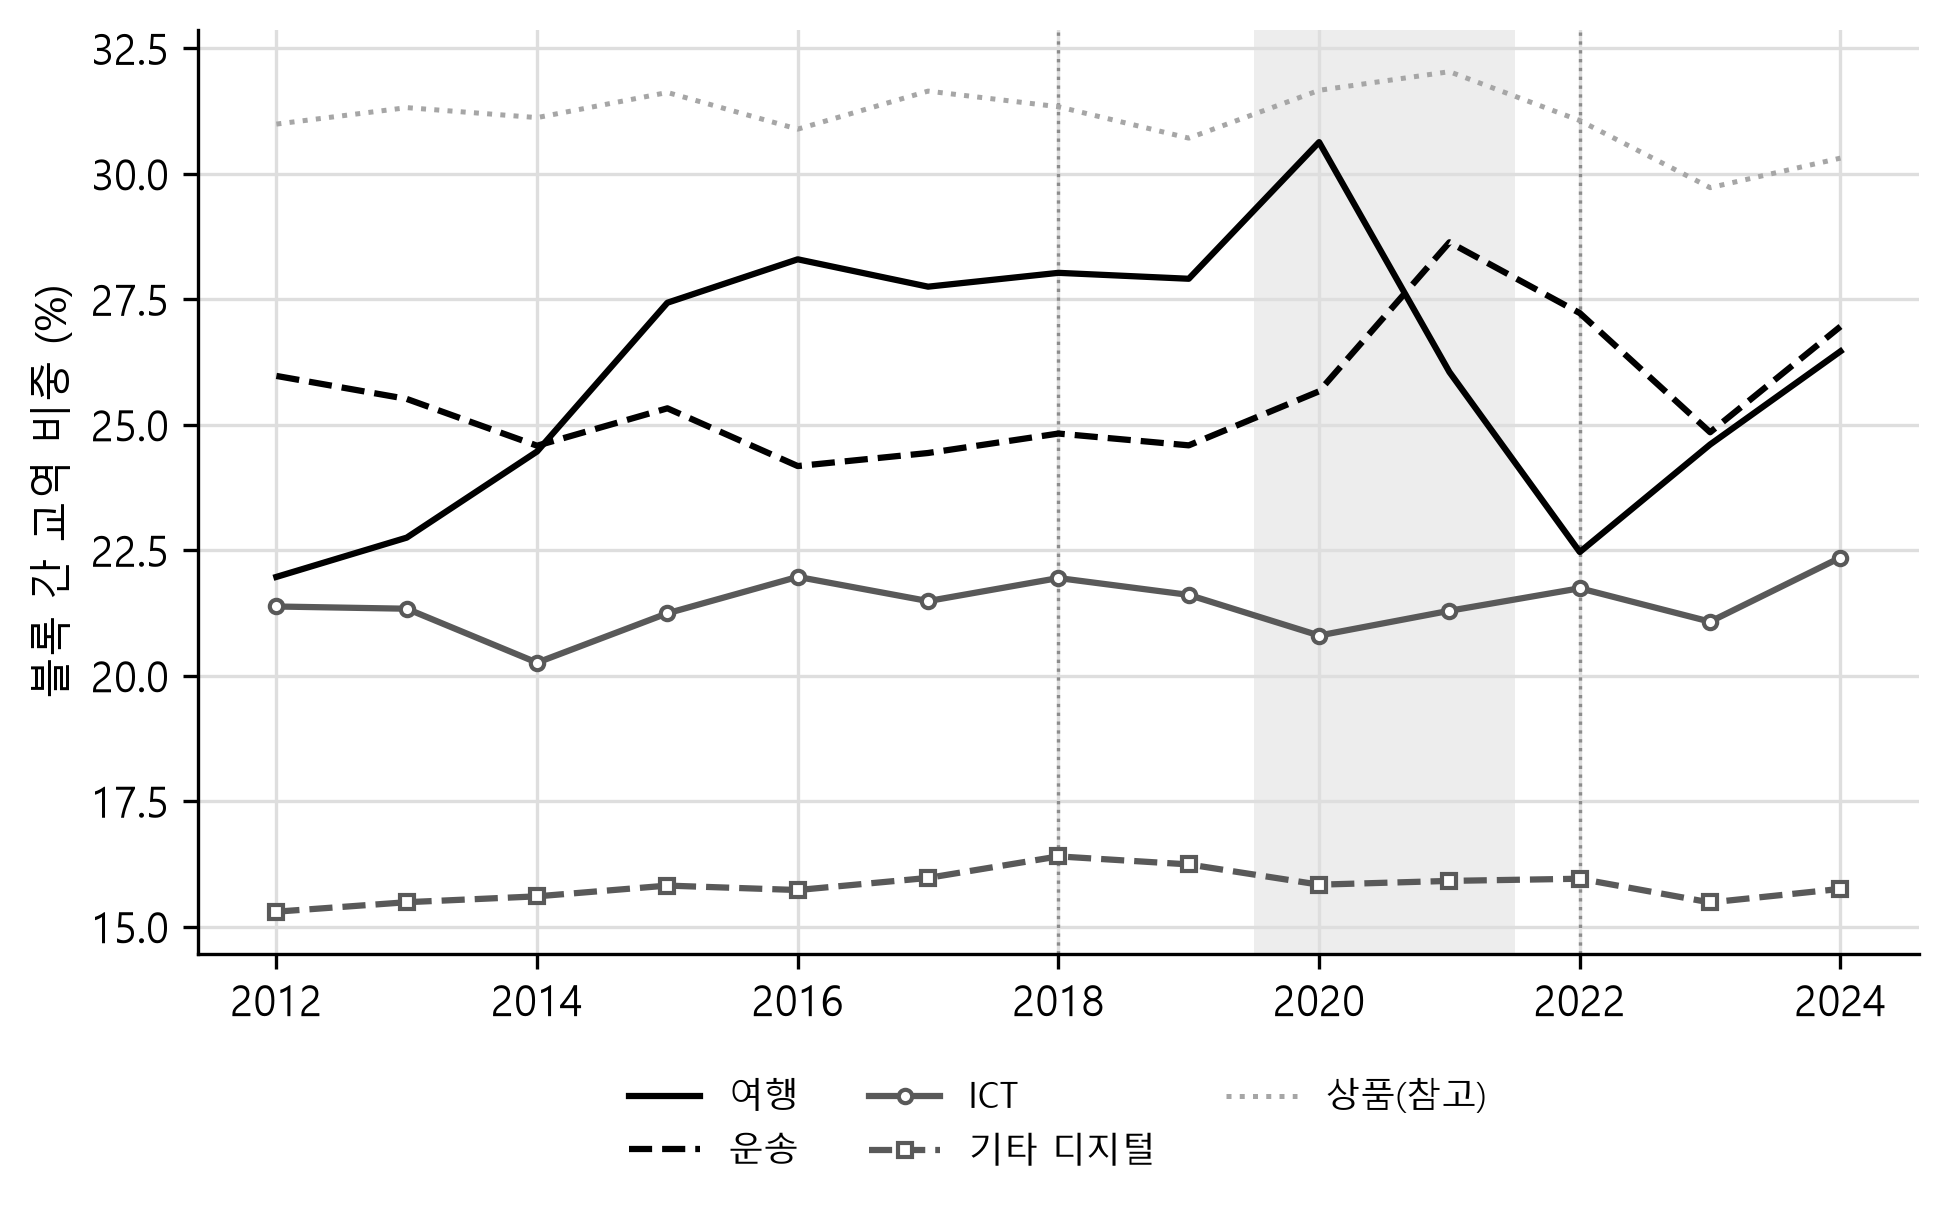

In [7]:
for d in ("D1", "D2", "D3", "D4"):
    print("==", d)
    print(pd.DataFrame(S["decomp"][d]).T.round(2))
print("== D1, 사후 2023~2024")
print(pd.DataFrame(S["decomp_D1_2023_24"]).T.round(2))
display(Image(os.path.join(HERE, "img", "fig2_categories.png"), width=700))

## §6. 집약도

In [8]:
main.pivot(index="defn", columns="series", values="dI_pct").round(2)

series,goods_b,goods_baci,goods_rx,svc_bal,svc_rep
defn,,,,,
D1,1.01,0.70,-1.39,1.71,7.29
D2,-1.99,-1.97,-4.09,-1.53,5.66
D3,1.10,0.42,-1.24,-0.73,8.92
D4,-2.13,-1.92,-3.39,1.35,4.35


## §7. 교역망

      svc_ari  goods_ari  svc_ncom  goods_ncom  svc_q_d1  goods_q_d1  svc_q_d3  goods_q_d3
2012    0.165      0.300      5.35        4.00     0.083       0.069     0.087       0.096
2013    0.177      0.266      5.35        3.95     0.083       0.073     0.089       0.095
2014    0.208      0.281      5.05        4.00     0.085       0.082     0.091       0.101
2015    0.212      0.285      5.00        4.10     0.082       0.091     0.091       0.110
2016    0.171      0.315      5.40        4.75     0.081       0.090     0.092       0.109
2017    0.182      0.303      5.15        4.50     0.082       0.093     0.093       0.107
2018    0.201      0.299      5.20        4.40     0.085       0.092     0.095       0.109
2019    0.190      0.321      5.65        4.85     0.088       0.095     0.096       0.113
2020    0.175      0.372      5.00        3.80     0.084       0.104     0.093       0.121
2021    0.208      0.331      4.95        3.95     0.084       0.107     0.092       0.123

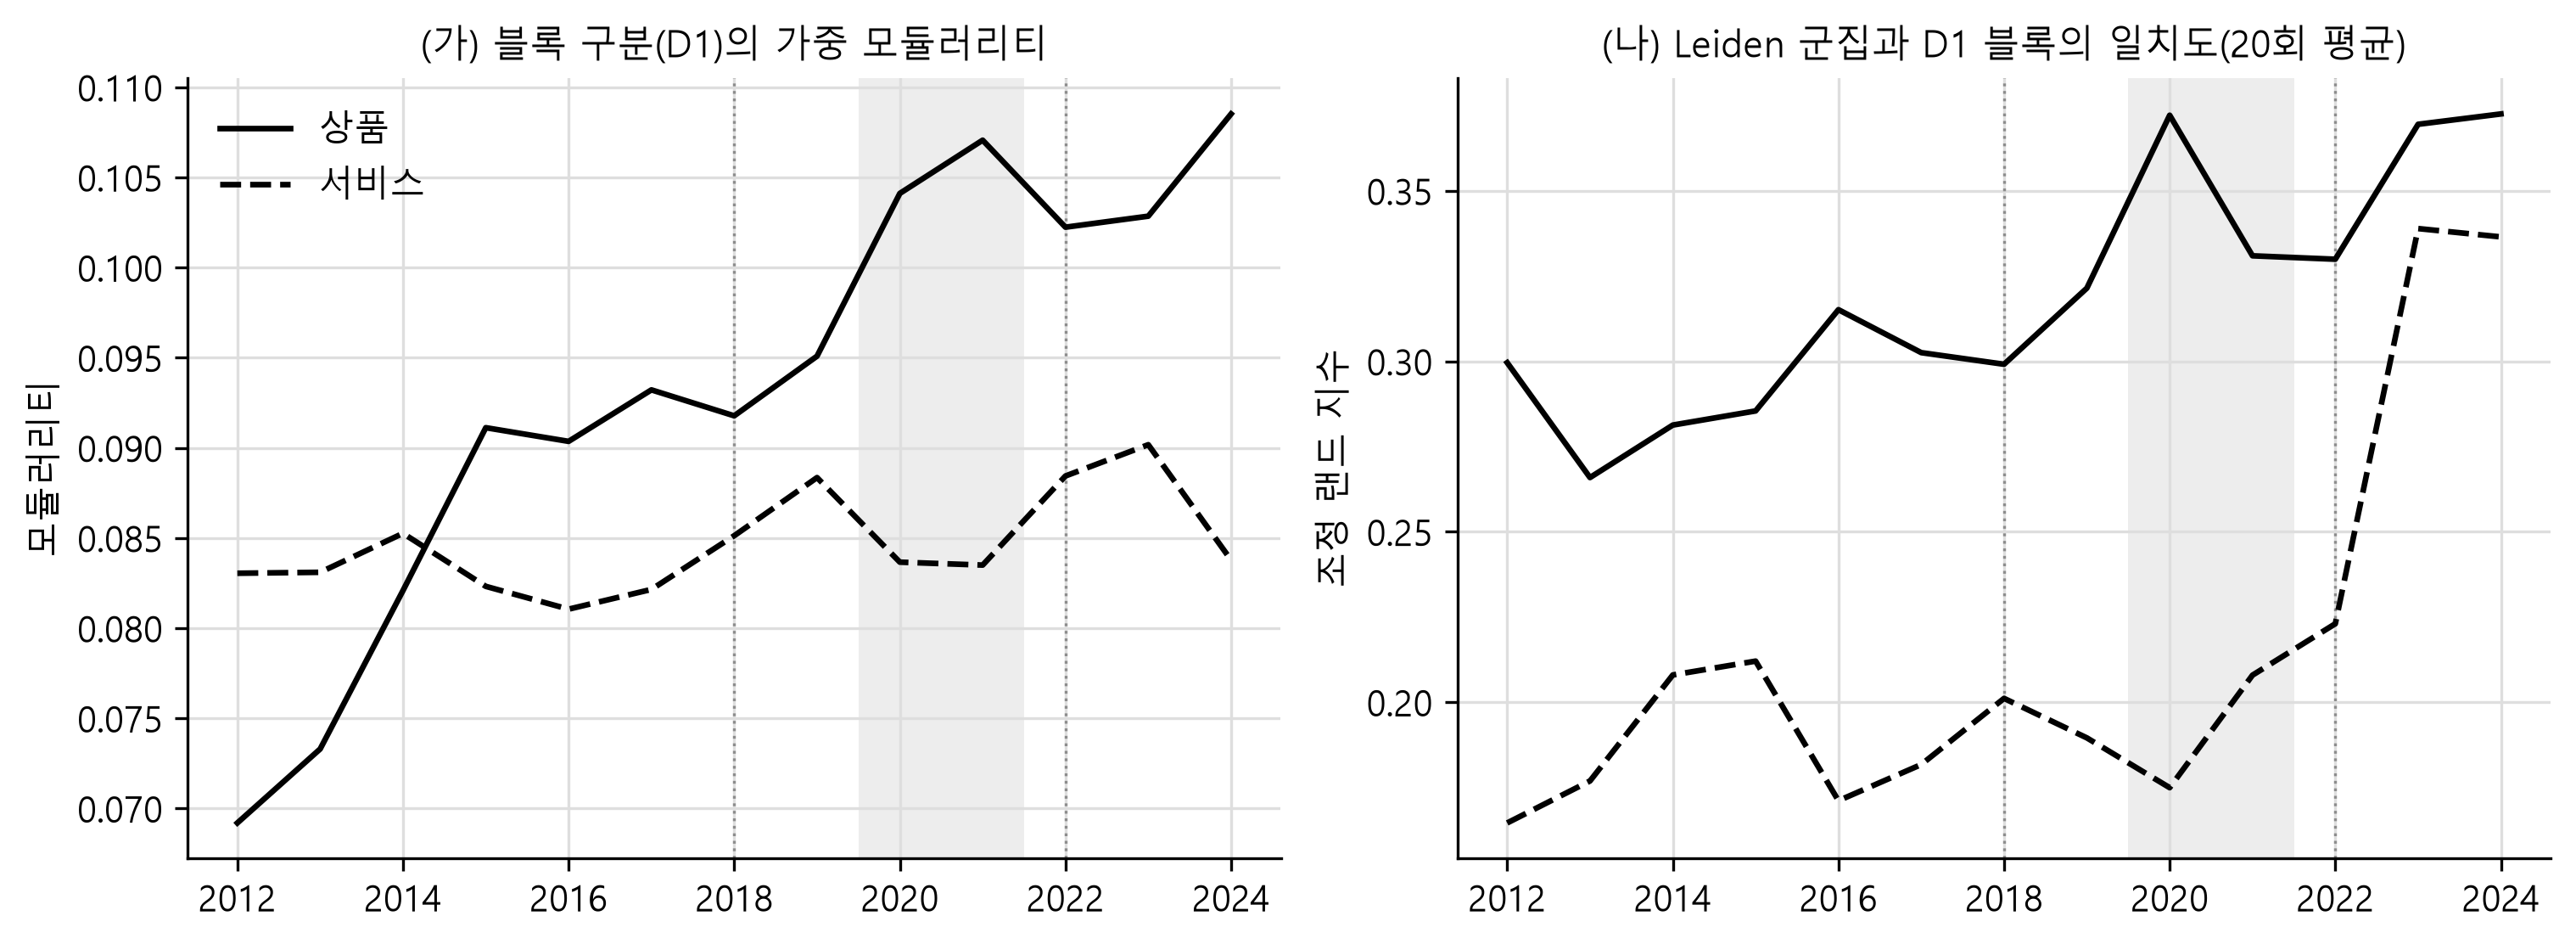

In [9]:
print(pd.DataFrame(S["network"]["annual"]).T.round(3))
print("사전", S["network"]["pre"]); print("사후", S["network"]["post"])
display(Image(os.path.join(HERE, "img", "fig3_network.png"), width=900))

## §8. 독립 재계산

분석 스크립트의 논리를 쓰지 않고 SQL만으로 D1 기준 서비스 균형치와 상품의 사전·사후 블록 간 비중을 계산해
`analysis.py`의 값과 맞춘다. 패널 정의(다섯 해 모두 한쪽이라도 보고)도 여기서 다시 만든다.

In [10]:
con = duckdb.connect()
con.execute(f"ATTACH '{DB}' AS s (READ_ONLY)")
con.register("bl", blocs[["code", "D1"]])
indep = con.execute('''
WITH e AS (SELECT year, reporter i, partner j, balanced_value bal, reported_value rx
           FROM s.fact_batis WHERE item_code='S' AND flow='EXP'),
     m AS (SELECT year, partner i, reporter j, reported_value rm
           FROM s.fact_batis WHERE item_code='S' AND flow='IMP'),
     f AS (SELECT e.*, m.rm FROM e LEFT JOIN m USING (year, i, j)
           JOIN s.dim_area a ON e.i=a.code AND NOT a.is_aggregate
           JOIN s.dim_area b ON e.j=b.code AND NOT b.is_aggregate),
     pnl AS (SELECT i, j FROM f WHERE year IN (2015,2016,2017,2022,2023)
             GROUP BY 1,2 HAVING sum((rx IS NOT NULL OR rm IS NOT NULL)::INT) = 5),
     svc AS (SELECT f.year, f.i, f.j, f.bal v FROM f JOIN pnl USING (i, j)),
     gd AS (SELECT g.year, g.exporter i, g.importer j, g.value v FROM s.fact_bimts_hs2 g
            JOIN pnl ON g.exporter=pnl.i AND g.importer=pnl.j
            WHERE g.product='_T' AND g.adjustment='B_ADJ_RX'),
     allx AS (SELECT 'svc' ser, * FROM svc UNION ALL SELECT 'goods', * FROM gd),
     t AS (SELECT allx.*, bi.D1 bi, bj.D1 bj,
                  CASE WHEN year BETWEEN 2015 AND 2017 THEN 'pre' WHEN year BETWEEN 2022 AND 2024 THEN 'post' END per
           FROM allx JOIN bl bi ON allx.i=bi.code JOIN bl bj ON allx.j=bj.code
           WHERE bi.D1 IN ('US','CN') AND bj.D1 IN ('US','CN'))
SELECT ser, per, 100.0*sum(v) FILTER (WHERE bi<>bj)/sum(v) S
FROM t WHERE per IS NOT NULL GROUP BY 1,2 ORDER BY 1,2
''').df().pivot(index="ser", columns="per", values="S")
indep["d_post"] = indep["post"] - indep["pre"]
print(indep.round(3))
a_svc = S["main"]["D1|svc_bal"]; a_gd = S["main"]["D1|goods_rx"]
assert abs(indep.loc["svc", "d_post"] - a_svc["d_post"]) < 0.01
assert abs(indep.loc["goods", "d_post"] - a_gd["d_post"]) < 0.01
print("독립 재계산 일치")

per      post     pre  d_post
ser                          
goods  30.373  31.393  -1.019
svc    19.868  20.704  -0.836
독립 재계산 일치


## §9. 본문 수치 검증

본문이 인용한 값과 `out/stats.json`의 값을 대조한다. 본문을 고치면 이 절도 함께 고친다.

In [11]:
def chk(name, got, want, tol=0.006):
    ok = got is not None and abs(got - want) <= tol
    print(("OK  " if ok else "FAIL") + f" {name}: 계산 {got} / 본문 {want}")
    assert ok, f"{name}: 계산 {got} != 본문 {want}"

M = S["main"]
# II.1 표본
chk("패널 방향쌍", S["panel"]["n_pairs"], 9196, 0)
chk("패널 경제 수", S["panel"]["n_economies"], 201, 0)
chk("서비스 포괄 2019", S["panel"]["svc_cover_2019"], 82.3, 0.05)
chk("서비스 포괄 2023", S["panel"]["svc_cover_2023"], 83.8, 0.05)
chk("상품 포괄 2019", S["panel"]["goods_cover_2019"], 75.8, 0.05)
chk("상품 포괄 2023", S["panel"]["goods_cover_2023"], 74.1, 0.05)
assert S["panel"]["usa_chn_in"]

# II.2 블록
for d, (u, c, n) in {"D1": (58, 51, 95), "D2": (57, 50, 96), "D3": (56, 8, 147)}.items():
    chk(f"{d} 미국 쪽", S["blocs"][d]["US"], u, 0); chk(f"{d} 중국 쪽", S["blocs"][d]["CN"], c, 0)
    chk(f"{d} 비동맹", S["blocs"][d]["NON"], n, 0)
chk("D4 미국 쪽", S["blocs"]["D4"]["US"], 56, 0); chk("D4 비서방", S["blocs"]["D4"]["CN"], 148, 0)
chk("D1-D2 대상 경제", S["blocs"]["d1_d2_n"], 203, 0)
chk("D1-D2 블록 이동", S["blocs"]["d1_d2_switch"], 88, 0)

# III.1 그림 1 인용
A1, A3 = S["annual_D1"], S["annual_D3"]
chk("D1 서비스 2017", A1["2017"]["svc_bal"], 20.65); chk("D1 서비스 2018", A1["2018"]["svc_bal"], 21.01)
chk("D1 상품 2017", A1["2017"]["goods_rx"], 31.65); chk("D1 상품 2019", A1["2019"]["goods_rx"], 30.71)
chk("D1 상품 2021", A1["2021"]["goods_rx"], 32.03)
chk("D3 상품 2021", A3["2021"]["goods_rx"], 29.19); chk("D3 상품 2023", A3["2023"]["goods_rx"], 24.68)
chk("D3 서비스 2021", A3["2021"]["svc_bal"], 14.19); chk("D3 서비스 2023", A3["2023"]["svc_bal"], 11.74)

# III.2 표 2
T2 = {
 "D1|svc_bal": (20.70, 0.86, 0.14, -0.84, -0.052), "D1|svc_rep": (18.84, None, 0.02, -1.55, -0.104),
 "D1|goods_rx": (31.39, 0.25, -0.37, -1.02, -0.048), "D1|goods_b": (31.64, 0.45, -0.33, -0.81, -0.038),
 "D1|goods_baci": (32.86, 0.43, -0.14, -0.43, -0.019),
 "D2|svc_bal": (19.94, 0.46, -0.54, -2.74, -0.181), "D2|svc_rep": (18.01, None, -0.67, -3.50, -0.258),
 "D2|goods_rx": (34.00, -1.21, -0.17, -2.08, -0.094), "D2|goods_b": (34.12, -1.03, -0.10, -1.76, -0.079),
 "D2|goods_baci": (35.33, -1.05, 0.10, -1.57, -0.069),
 "D3|svc_bal": (14.56, 0.51, -0.04, -2.18, -0.187), "D3|svc_rep": (12.73, None, 0.05, -2.25, -0.220),
 "D3|goods_rx": (28.28, -0.23, -0.24, -2.66, -0.135), "D3|goods_b": (28.61, -0.01, -0.23, -2.44, -0.123),
 "D3|goods_baci": (29.59, 0.06, -0.13, -2.44, -0.120),
 "D4|svc_bal": (31.03, 0.17, -0.24, -1.06, -0.050), "D4|svc_rep": (28.86, None, -0.53, -1.97, -0.098),
 "D4|goods_rx": (44.26, -0.92, -0.37, -1.43, -0.058), "D4|goods_b": (44.16, -0.80, -0.32, -1.17, -0.048),
 "D4|goods_baci": (45.49, -0.70, -0.13, -0.89, -0.036),
}
for k, (lvl, pt, war, post, lo) in T2.items():
    chk(f"{k} 사전 수준", M[k]["S_pre"], lvl)
    if pt is None:
        assert M[k]["d_pretrend"] is None
    else:
        chk(f"{k} 사전 추세", M[k]["d_pretrend"], pt)
    chk(f"{k} 무역분쟁", M[k]["d_war"], war)
    chk(f"{k} 사후", M[k]["d_post"], post)
    chk(f"{k} 로그 오즈", M[k]["dlogodds_post"], lo, 0.0006)

ratio = {d: M[f"{d}|svc_bal"]["d_post"] / M[f"{d}|goods_rx"]["d_post"] for d in ("D1", "D2", "D3", "D4")}
for d, w in (("D1", 0.82), ("D2", 1.32), ("D3", 0.82), ("D4", 0.74)):
    chk(f"{d} 서비스/상품 하락 비", round(ratio[d], 2), w, 0.001)
chk("D3 서비스 증가율 차이(%)", round(100 * (np.exp(M["D3|svc_bal"]["dlogodds_post"]) - 1), 1), -17.1, 0.05)
chk("D3 상품 증가율 차이(%)", round(100 * (np.exp(M["D3|goods_rx"]["dlogodds_post"]) - 1), 1), -12.6, 0.05)

B = S["bootstrap_D1"]
chk("부트스트랩 수출국", B["n_exporters"], 105, 0)
chk("서비스 구간 하한", B["svc_bal"]["lo"], -2.11); chk("서비스 구간 상한", B["svc_bal"]["hi"], 0.81)
chk("상품 구간 하한", B["goods_rx"]["lo"], -2.44); chk("상품 구간 상한", B["goods_rx"]["hi"], 0.47)
chk("차이 구간 하한", B["diff_bal"]["lo"], -1.09); chk("차이 구간 상한", B["diff_bal"]["hi"], 1.77)

# III.3 표 3과 러시아
R = S["russia_exclusion"]
T3 = {"D1": (-0.84, -0.82, -1.55, -1.53, -1.02, -1.00), "D2": (-2.74, -1.82, -3.50, -2.78, -2.08, -0.99),
      "D3": (-2.18, -1.11, -2.25, -1.42, -2.66, -1.44), "D4": (-1.06, -0.38, -1.97, -1.44, -1.43, -0.67)}
for d, v in T3.items():
    for (ser, i0) in (("svc_bal", 0), ("svc_rep", 2), ("goods_rx", 4)):
        chk(f"{d} {ser} 전체", R[f"{d}|{ser}"]["d_all"], v[i0]); chk(f"{d} {ser} 제외", R[f"{d}|{ser}"]["d_exrus"], v[i0 + 1])
cut_g = [100 * (1 - R[f"{d}|goods_rx"]["d_exrus"] / R[f"{d}|goods_rx"]["d_all"]) for d in ("D2", "D3", "D4")]
cut_s = [100 * (1 - R[f"{d}|svc_bal"]["d_exrus"] / R[f"{d}|svc_bal"]["d_all"]) for d in ("D2", "D3", "D4")]
chk("상품 감소율 최소", round(min(cut_g)), 46, 0); chk("상품 감소율 최대", round(max(cut_g)), 53, 0)
chk("서비스 감소율 최소", round(min(cut_s)), 34, 0); chk("서비스 감소율 최대", round(max(cut_s)), 64, 0)
chk("러시아 무보고 사전", S["russia_quality"]["pre"]["none_pct"], 0.4, 0.05)
chk("러시아 무보고 사후", S["russia_quality"]["post"]["none_pct"], 43.4, 0.05)
RM = S["russia_mirror"]
chk("러시아 균형치 2019", RM["2019"]["bal"], 27738, 0.5); chk("러시아 균형치 2023", RM["2023"]["bal"], 15724, 0.5)
chk("러시아 균형치 감소(%)", round(100 * (1 - RM["2023"]["bal"] / RM["2019"]["bal"]), 1), 43.3, 0.05)
chk("러시아 거울상 2019", RM["2019"]["mirror"], 20341, 0.5); chk("러시아 거울상 2023", RM["2023"]["mirror"], 9105, 0.5)
chk("러시아 거울상 감소(%)", round(100 * (1 - RM["2023"]["mirror"] / RM["2019"]["mirror"]), 1), 55.2, 0.05)

# III.4 표 4와 범주
D = S["decomp"]["D1"]
T4 = {"여행": (21.73, 16.36, 27.83, 24.79, -3.04, -1.41, -0.58), "운송": (16.74, 17.24, 24.65, 26.38, 1.73, 0.13, 0.29),
      "ICT": (8.86, 11.75, 21.56, 21.74, 0.18, 0.63, 0.02), "기타 디지털": (46.97, 49.14, 15.84, 15.72, -0.12, 0.34, -0.06),
      "기타": (5.70, 5.50, 20.70, 17.86, -2.84, -0.04, -0.16)}
for g, vals in T4.items():
    for key, w in zip(("w_pre", "w_post", "s_pre", "s_post", "ds", "composition", "within"), vals):
        chk(f"D1 {g} {key}", D[g][key], w)
chk("D1 구성 합", D["_total"]["composition"], -0.35); chk("D1 범주 내 합", D["_total"]["within"], -0.48)
for d, ict_w, trav in (("D2", -0.04, -2.45), ("D3", 0.05, -2.27), ("D4", -0.09, -2.48)):
    chk(f"{d} ICT 범주 내", S["decomp"][d]["ICT"]["within"], ict_w)
    chk(f"{d} 여행 합", round(S["decomp"][d]["여행"]["composition"] + S["decomp"][d]["여행"]["within"], 2), trav, 0.011)
ict_comp = [S["decomp"][d]["ICT"]["composition"] for d in ("D1", "D2", "D3", "D4")]
chk("ICT 구성 최소", min(ict_comp), 0.30); chk("ICT 구성 최대", max(ict_comp), 0.82)
chk("D2 기타 디지털 범주 내", S["decomp"]["D2"]["기타 디지털"]["within"], -0.88)
chk("D3 기타 디지털 범주 내", S["decomp"]["D3"]["기타 디지털"]["within"], -0.52)
L = S["decomp_D1_2023_24"]["여행"]
chk("2023~24 여행 구성", L["composition"], -1.13); chk("2023~24 여행 범주 내", L["within"], -0.44)
C = S["annual_category_D1"]
chk("여행 2020", C["2020"]["여행"], 30.6, 0.05); chk("여행 2022", C["2022"]["여행"], 22.5, 0.05)
chk("여행 2024", C["2024"]["여행"], 26.5, 0.05)
ict = [C[y]["ICT"] for y in C]
chk("ICT 최소", round(min(ict), 1), 20.3, 0.05); chk("ICT 최대", round(max(ict), 1), 22.4, 0.05)

# III.5 표 5
T5 = {"D1": (1.71, 7.29, -1.39, 1.01, 0.70), "D2": (-1.53, 5.66, -4.09, -1.99, -1.97),
      "D3": (-0.73, 8.92, -1.24, 1.10, 0.42), "D4": (1.35, 4.35, -3.39, -2.13, -1.92)}
for d, vals in T5.items():
    for ser, w in zip(("svc_bal", "svc_rep", "goods_rx", "goods_b", "goods_baci"), vals):
        chk(f"{d} {ser} 집약도", M[f"{d}|{ser}"]["dI_pct"], w)

# III.6 교역망
N = S["network"]
chk("노드 수", N["n_nodes"], 80, 0)
chk("상품 Q 2012", N["annual"]["2012"]["goods_q_d1"], 0.069, 0.0006); chk("상품 Q 2024", N["annual"]["2024"]["goods_q_d1"], 0.109, 0.0006)
chk("상품 Q 사전", N["pre"]["goods_q_d1"], 0.092, 0.0006); chk("상품 Q 사후", N["post"]["goods_q_d1"], 0.105, 0.0006)
chk("서비스 Q 사전", N["pre"]["svc_q_d1"], 0.082, 0.0006); chk("서비스 Q 사후", N["post"]["svc_q_d1"], 0.087, 0.0006)
sq = [N["annual"][y]["svc_q_d1"] for y in N["annual"]]
chk("서비스 Q 최소", min(sq), 0.081, 0.0006); chk("서비스 Q 최대", max(sq), 0.090, 0.0006)
chk("D3 상품 Q 사전", N["pre"]["goods_q_d3"], 0.109, 0.0006); chk("D3 상품 Q 사후", N["post"]["goods_q_d3"], 0.127, 0.0006)
chk("D3 서비스 Q 사전", N["pre"]["svc_q_d3"], 0.092, 0.0006); chk("D3 서비스 Q 사후", N["post"]["svc_q_d3"], 0.098, 0.0006)
chk("서비스 ARI 2022", N["annual"]["2022"]["svc_ari"], 0.223, 0.0006); chk("서비스 ARI 2023", N["annual"]["2023"]["svc_ari"], 0.339, 0.0006)
chk("서비스 군집 수 2022", N["annual"]["2022"]["svc_ncom"], 4.9, 0.001); chk("서비스 군집 수 2023", N["annual"]["2023"]["svc_ncom"], 4.0, 0.001)

# 부록 A
T = S["taiwan_hk_D1"]
chk("대만·홍콩 서비스 기준", T["svc_bal|base"], -0.84); chk("대만·홍콩 서비스 제외", T["svc_bal|ex_twhk"], -0.88)
chk("대만·홍콩 상품 기준", T["goods_rx|base"], -1.02); chk("대만·홍콩 상품 제외", T["goods_rx|ex_twhk"], -0.63)
chk("상품 감소율(%)", round(100 * (1 - T["goods_rx|ex_twhk"] / T["goods_rx|base"])), 38, 0)
print("\n모든 검증 통과")

OK   패널 방향쌍: 계산 9196 / 본문 9196
OK   패널 경제 수: 계산 201 / 본문 201
OK   서비스 포괄 2019: 계산 82.3 / 본문 82.3
OK   서비스 포괄 2023: 계산 83.8 / 본문 83.8
OK   상품 포괄 2019: 계산 75.8 / 본문 75.8
OK   상품 포괄 2023: 계산 74.1 / 본문 74.1
OK   D1 미국 쪽: 계산 58 / 본문 58
OK   D1 중국 쪽: 계산 51 / 본문 51
OK   D1 비동맹: 계산 95 / 본문 95
OK   D2 미국 쪽: 계산 57 / 본문 57
OK   D2 중국 쪽: 계산 50 / 본문 50
OK   D2 비동맹: 계산 96 / 본문 96
OK   D3 미국 쪽: 계산 56 / 본문 56
OK   D3 중국 쪽: 계산 8 / 본문 8
OK   D3 비동맹: 계산 147 / 본문 147
OK   D4 미국 쪽: 계산 56 / 본문 56
OK   D4 비서방: 계산 148 / 본문 148
OK   D1-D2 대상 경제: 계산 203 / 본문 203
OK   D1-D2 블록 이동: 계산 88 / 본문 88
OK   D1 서비스 2017: 계산 20.65 / 본문 20.65
OK   D1 서비스 2018: 계산 21.01 / 본문 21.01
OK   D1 상품 2017: 계산 31.65 / 본문 31.65
OK   D1 상품 2019: 계산 30.71 / 본문 30.71
OK   D1 상품 2021: 계산 32.03 / 본문 32.03
OK   D3 상품 2021: 계산 29.19 / 본문 29.19
OK   D3 상품 2023: 계산 24.68 / 본문 24.68
OK   D3 서비스 2021: 계산 14.19 / 본문 14.19
OK   D3 서비스 2023: 계산 11.74 / 본문 11.74
OK   D1|svc_bal 사전 수준: 계산 20.7 / 본문 20.7
OK   D1|svc_bal 사전 추세: 계산 0.86 / 본문 0.86
OK   D